In [2]:
import pandas as pd #Used for data management
import numpy as np #Used for mathematical calculations
import matplotlib.pyplot as plt #Used for creating graphs
import seaborn as sns #Used for creating graphs
import geopandas as gpd #Used for creating map plots
import matplotlib.colors as mpc #Used for creating logarithmic scale
import matplotlib.patches as mpatches #Used for sorting of categorical data legends

In [3]:
svi_data = pd.read_csv('CIVE202_Project5_SVI_2022_US_county_Wiggins&Anciaux.csv') #Imports SVI data
fema_data = pd.read_csv('FEMA_HurricanePaths_US.csv') #Imports FEMA hurricane path data
tracts = gpd.read_file('nri_shape_file') #Imports NRI data with shapefile

In [4]:
states = gpd.read_file("cb_2024_us_state_500k.zip") #Imports US Census Bureau US state outline shapefile

In [5]:
tracts_clean = tracts.set_crs(epsg = 4326, inplace = True, allow_override = True) #Checks and sets projection

tracts_clean = tracts_clean.to_crs(epsg = 4326) #Changes CRS

tracts_clean = tracts_clean.replace(-9999, np.nan) #Replaces -9999 nulls with NaN


In [6]:
tracts_clean.crs = "EPSG:3857" #Changes projection

tracts_clean = tracts_clean.to_crs(epsg=4326) #Changes to degrees to match limits

tracts_clean = tracts_clean.to_crs("ESRI:102003") #Sets to standard US lower 48 projection


In [67]:
print(tracts_clean['STATE'].unique())

['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Delaware' 'District of Columbia' 'Florida' 'Georgia'
 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky'
 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota'
 'Mississippi' 'Missouri' 'Montana' 'Nebraska' 'Nevada' 'New Hampshire'
 'New Jersey' 'New Mexico' 'New York' 'North Carolina' 'North Dakota'
 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania' 'Rhode Island' 'South Carolina'
 'South Dakota' 'Tennessee' 'Texas' 'Utah' 'Vermont' 'Virginia'
 'Washington' 'West Virginia' 'Wisconsin' 'Wyoming' 'American Samoa'
 'Guam' 'Northern Mariana Islands' 'Puerto Rico' 'Virgin Islands']


In [68]:
exclude = ['Alaska', 'Hawaii', 'Puerto Rico', 'American Samoa', 'Guam', 'Northern Mariana Islands', 'Virgin Islands', 'Arizona', 
           'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 
           'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 
           'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 
           'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 
           'Wisconsin', 'Wyoming', 'District of Columbia']

# Filter if your column is named 'STATE'
tracts_final = tracts_clean[~tracts_clean['STATE'].isin(exclude)]

In [7]:
points = gpd.GeoDataFrame(fema_data, geometry = gpd.points_from_xy(fema_data['LON'], fema_data['LAT']), crs = 'NAD83') 
#Creates a dataset of geographical points from the FEMA data's longitude and latitude

In [8]:
points = points.to_crs(states.crs) #Sets the coordinates to NAD83 coordinate system

In [7]:
points

,OBJECTID,SID,BASIN,SUBBASIN,NAME,NATURE,LAT,LON,USA_WIND,USA_PRES,year,month,day,Hurricane_Date,geometry
0,477954,1990145N19276,NaN,CS,UNNAMED,TS,20.2,-83.9,25,0,1990,5,25,5/25/1990 0:00,POINT (-83.9 20.2)
1,477955,1990145N19276,NaN,CS,UNNAMED,TS,20.7,-83.7,25,0,1990,5,25,5/25/1990 0:00,POINT (-83.7 20.7)
2,477956,1990145N19276,NaN,CS,UNNAMED,TS,21.2,-83.5,25,0,1990,5,25,5/25/1990 0:00,POINT (-83.5 21.2)
3,477957,1990145N19276,NaN,CS,UNNAMED,TS,21.8,-83.3,25,0,1990,5,25,5/25/1990 0:00,POINT (-83.3 21.8)
4,477958,1990145N19276,NaN,CS,UNNAMED,TS,22.4,-83.1,25,0,1990,5,25,5/25/1990 0:00,POINT (-83.1 22.4)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10660,708424,2025291N11319,NaN,NaN,MELISSA,TS,20.2,-76.1,100,960,2025,10,29,10/29/2025 0:00,POINT (-76.1 20.2)
10661,708425,2025291N11319,NaN,NaN,MELISSA,TS,20.8,-75.8,90,968,2025,10,29,10/29/2025 0:00,POINT (-75.8 20.8)
10662,708426,2025291N11319,NaN,NaN,MELISSA,TS,21.4,-75.5,85,971,2025,10,29,10/29/2025 0:00,POINT (-75.5 21.4)
10663,708427,2025291N11319,NaN,NaN,MELISSA,TS,22.1,-75.3,80,974,2025,10,29,10/29/2025 0:00,POINT (-75.3 22.1)


In [9]:
joined = gpd.sjoin(points, states, how = 'left', predicate = 'within') 
#Performs spacial join to place FEMA data points on US state outline
joined

,OBJECTID,SID,BASIN,SUBBASIN,NAME_left,NATURE,LAT,LON,USA_WIND,USA_PRES,...,index_right,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME_right,LSAD,ALAND,AWATER
0,477954,1990145N19276,NaN,CS,UNNAMED,TS,20.2,-83.9,25,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,477955,1990145N19276,NaN,CS,UNNAMED,TS,20.7,-83.7,25,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,477956,1990145N19276,NaN,CS,UNNAMED,TS,21.2,-83.5,25,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,477957,1990145N19276,NaN,CS,UNNAMED,TS,21.8,-83.3,25,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,477958,1990145N19276,NaN,CS,UNNAMED,TS,22.4,-83.1,25,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10660,708424,2025291N11319,NaN,NaN,MELISSA,TS,20.2,-76.1,100,960,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10661,708425,2025291N11319,NaN,NaN,MELISSA,TS,20.8,-75.8,90,968,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10662,708426,2025291N11319,NaN,NaN,MELISSA,TS,21.4,-75.5,85,971,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10663,708427,2025291N11319,NaN,NaN,MELISSA,TS,22.1,-75.3,80,974,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
svi_data.columns

Index(['ST', 'STATE', 'ST_ABBR', 'STCNTY', 'COUNTY', 'FIPS', 'LOCATION',
       'AREA_SQMI', 'E_TOTPOP', 'M_TOTPOP',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=158)

In [10]:
#Creates individual dataset for each state
tx = svi_data[svi_data['STATE'] == 'Texas']
la = svi_data[svi_data['STATE'] == 'Louisiana']
ms = svi_data[svi_data['STATE'] == 'Mississippi']
al = svi_data[svi_data['STATE'] == 'Alabama']
ga = svi_data[svi_data['STATE'] == 'Georgia']
fl = svi_data[svi_data['STATE'] == 'Florida']

In [11]:
fema_data

,OBJECTID,SID,BASIN,SUBBASIN,NAME,NATURE,LAT,LON,USA_WIND,USA_PRES,year,month,day,Hurricane_Date
0,477954,1990145N19276,NaN,CS,UNNAMED,TS,20.2,-83.9,25,0,1990,5,25,5/25/1990 0:00
1,477955,1990145N19276,NaN,CS,UNNAMED,TS,20.7,-83.7,25,0,1990,5,25,5/25/1990 0:00
2,477956,1990145N19276,NaN,CS,UNNAMED,TS,21.2,-83.5,25,0,1990,5,25,5/25/1990 0:00
3,477957,1990145N19276,NaN,CS,UNNAMED,TS,21.8,-83.3,25,0,1990,5,25,5/25/1990 0:00
4,477958,1990145N19276,NaN,CS,UNNAMED,TS,22.4,-83.1,25,0,1990,5,25,5/25/1990 0:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10660,708424,2025291N11319,NaN,NaN,MELISSA,TS,20.2,-76.1,100,960,2025,10,29,10/29/2025 0:00
10661,708425,2025291N11319,NaN,NaN,MELISSA,TS,20.8,-75.8,90,968,2025,10,29,10/29/2025 0:00
10662,708426,2025291N11319,NaN,NaN,MELISSA,TS,21.4,-75.5,85,971,2025,10,29,10/29/2025 0:00
10663,708427,2025291N11319,NaN,NaN,MELISSA,TS,22.1,-75.3,80,974,2025,10,29,10/29/2025 0:00


In [12]:
svi_data

,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,1,Alabama,AL,1001,Autauga County,1001,"Autauga County, Alabama",594.454786,58761,0,...,1.1,0.4,0.1,0.1,0.0,0.1,3.3,1.0,0.2,0.3
1,1,Alabama,AL,1003,Baldwin County,1003,"Baldwin County, Alabama",1589.861817,233420,0,...,0.9,0.1,0.2,0.1,0.0,0.1,3.1,0.4,0.4,0.3
2,1,Alabama,AL,1005,Barbour County,1005,"Barbour County, Alabama",885.007619,24877,0,...,0.5,0.1,0.3,0.1,0.0,0.1,1.8,0.7,1.2,0.8
3,1,Alabama,AL,1007,Bibb County,1007,"Bibb County, Alabama",622.469286,22251,0,...,0.3,0.4,0.1,0.1,0.0,0.2,1.7,1.0,0.1,0.1
4,1,Alabama,AL,1009,Blount County,1009,"Blount County, Alabama",644.890376,59077,0,...,0.2,0.2,0.1,0.1,0.2,0.2,2.8,0.7,0.1,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688,48,Texas,TX,48499,Wood County,48499,"Wood County, Texas",645.242965,45341,0,...,0.6,0.1,0.1,0.1,0.0,0.1,2.8,0.6,0.3,0.2
689,48,Texas,TX,48501,Yoakum County,48501,"Yoakum County, Texas",799.714725,7630,0,...,0.5,0.6,0.0,0.7,0.0,0.7,1.0,1.1,0.5,0.6
690,48,Texas,TX,48503,Young County,48503,"Young County, Texas",914.497938,17903,0,...,0.3,0.6,0.4,0.3,0.0,0.3,1.3,0.7,0.6,0.7
691,48,Texas,TX,48505,Zapata County,48505,"Zapata County, Texas",998.411912,13896,0,...,0.2,0.2,0.0,0.4,0.0,0.4,0.7,0.6,0.0,0.4


In [13]:
fema_data['long_bins'] = pd.cut(fema_data['LON'], bins = range(-120, 70, 5)) #Adds column to FEMA data with binned longitude

binned_data = fema_data.groupby('long_bins', observed = True)['USA_WIND'].mean() #Sorts FEMA data by wind speed for graphing

In [14]:
sns.set_style('darkgrid') #Sets grid style for graphs
sns.set_palette('husl') #Sets default color palette for graphs

Text(0.5, 1.0, 'Average Wind Speed by Longitude - Gulf of Mexico')

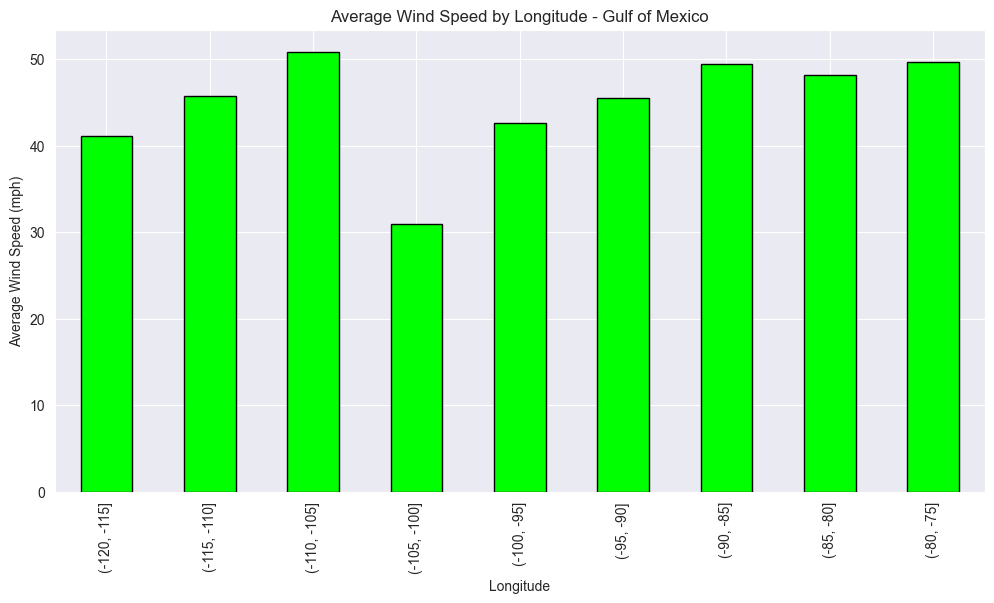

In [15]:
plt.figure(figsize = (12,6)) #Creates a 12x6 figure
binned_data.plot(kind = 'bar', edgecolor = 'black', color = 'lime') #Makes the figure a bar chart of the binned wind speeds, customizes it

#Adds labels and title
plt.xlabel('Longitude')
plt.ylabel('Average Wind Speed (mph)')
plt.title('Average Wind Speed by Longitude - Gulf of Mexico')

In [16]:
states

,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,35,00897535,0400000US35,35,NM,New Mexico,00,314198519809,726531289,"POLYGON ((-109.05017 31.48, -109.04984 31.4995..."
1,46,01785534,0400000US46,46,SD,South Dakota,00,196341670967,3387563375,"POLYGON ((-104.05788 44.9976, -104.05078 44.99..."
2,06,01779778,0400000US06,06,CA,California,00,403673433805,20291632828,"MULTIPOLYGON (((-118.60442 33.47855, -118.5987..."
3,21,01779786,0400000US21,21,KY,Kentucky,00,102266755818,2384136185,"MULTIPOLYGON (((-89.40565 36.52816, -89.39868 ..."
4,01,01779775,0400000US01,01,AL,Alabama,00,131185561946,4581813708,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."
5,13,01705317,0400000US13,13,GA,Georgia,00,149485762701,4419221858,"MULTIPOLYGON (((-81.27939 31.30792, -81.27716 ..."
6,05,00068085,0400000US05,05,AR,Arkansas,00,134658517854,3122715710,"POLYGON ((-94.61792 36.49941, -94.61765 36.499..."
7,42,01779798,0400000US42,42,PA,Pennsylvania,00,115881476238,3397613881,"POLYGON ((-80.51989 40.90666, -80.51963 40.911..."
8,29,01779791,0400000US29,29,MO,Missouri,00,178052403953,2487375487,"POLYGON ((-95.77355 40.5782, -95.76853 40.5833..."
9,08,01779779,0400000US08,08,CO,Colorado,00,268418973518,1185541418,"POLYGON ((-109.06025 38.59933, -109.05954 38.7..."


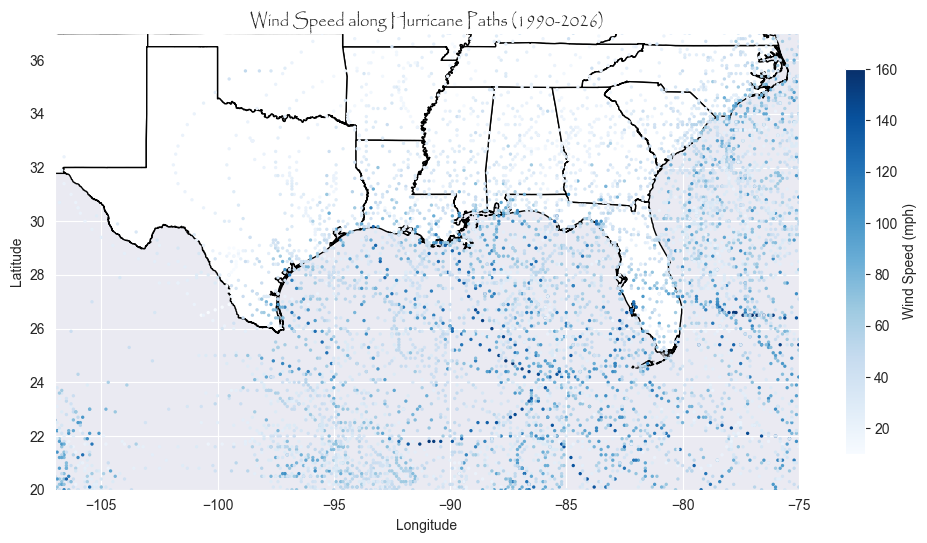

In [17]:
fig, ax = plt.subplots(figsize=(12, 20)) #Creates figure with grid-based layout


states.plot(ax=ax, color='white', edgecolor='black') #Plots US state shapfile

# Plot the joined points, colored by a specific attribute from the CSV
joined.plot(ax=ax, column='USA_WIND', cmap='Blues', markersize=2, legend=True, legend_kwds={'shrink': 0.25, 'label': 'Wind Speed (mph)'})
#Plots the wind speed at each spacial data point from the FEMA dataset

#Sets axis limits by longitude and latitude
ax.set_xlim([-107, -75])  
ax.set_ylim([20, 37])

#Adds title and labels
plt.title('Wind Speed along Hurricane Paths (1990-2026)', fontname = 'papyrus')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

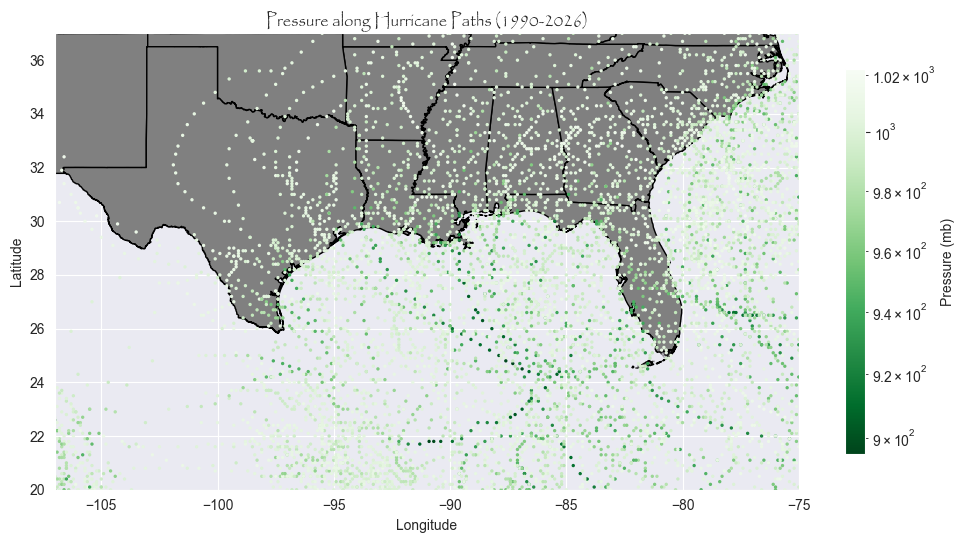

In [20]:
fig, ax = plt.subplots(figsize=(12, 20)) #Creates figure with grid layout


states.plot(ax=ax, color='grey', edgecolor='black') #Plots US state outline shapefile

# Plots the joined points, colored by pressure from the CSV
joined.plot(ax=ax, column='USA_PRES', cmap='Greens_r', markersize=2, legend=True, legend_kwds={'shrink': 0.25, 'label' : 'Pressure (mb)'}, norm = mpc.LogNorm())

#Sets axis limits
ax.set_xlim([-107, -75])  
ax.set_ylim([20, 37])

#Creates title and labels
plt.title('Pressure along Hurricane Paths (1990-2026)', fontname = 'papyrus')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

In [8]:
svi_data['STUSPS'] = svi_data['ST_ABBR'] #Creates a column in SVI data with the same name as one in the shapefile
complete_data = pd.merge(svi_data, states, on = 'STUSPS') #Merges the SVI data and state shapefile on STUSPS column
complete_data

,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,STUSPS,STATEFP,STATENS,GEOIDFQ,GEOID,NAME,LSAD,ALAND,AWATER,geometry
0,1,Alabama,AL,1001,Autauga County,1001,"Autauga County, Alabama",594.454786,58761,0,...,AL,01,01779775,0400000US01,01,Alabama,00,131185561946,4581813708,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."
1,1,Alabama,AL,1003,Baldwin County,1003,"Baldwin County, Alabama",1589.861817,233420,0,...,AL,01,01779775,0400000US01,01,Alabama,00,131185561946,4581813708,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."
2,1,Alabama,AL,1005,Barbour County,1005,"Barbour County, Alabama",885.007619,24877,0,...,AL,01,01779775,0400000US01,01,Alabama,00,131185561946,4581813708,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."
3,1,Alabama,AL,1007,Bibb County,1007,"Bibb County, Alabama",622.469286,22251,0,...,AL,01,01779775,0400000US01,01,Alabama,00,131185561946,4581813708,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."
4,1,Alabama,AL,1009,Blount County,1009,"Blount County, Alabama",644.890376,59077,0,...,AL,01,01779775,0400000US01,01,Alabama,00,131185561946,4581813708,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688,48,Texas,TX,48499,Wood County,48499,"Wood County, Texas",645.242965,45341,0,...,TX,48,01779801,0400000US48,48,Texas,00,676656702022,19011620342,"MULTIPOLYGON (((-94.7183 29.72886, -94.71721 2..."
689,48,Texas,TX,48501,Yoakum County,48501,"Yoakum County, Texas",799.714725,7630,0,...,TX,48,01779801,0400000US48,48,Texas,00,676656702022,19011620342,"MULTIPOLYGON (((-94.7183 29.72886, -94.71721 2..."
690,48,Texas,TX,48503,Young County,48503,"Young County, Texas",914.497938,17903,0,...,TX,48,01779801,0400000US48,48,Texas,00,676656702022,19011620342,"MULTIPOLYGON (((-94.7183 29.72886, -94.71721 2..."
691,48,Texas,TX,48505,Zapata County,48505,"Zapata County, Texas",998.411912,13896,0,...,TX,48,01779801,0400000US48,48,Texas,00,676656702022,19011620342,"MULTIPOLYGON (((-94.7183 29.72886, -94.71721 2..."


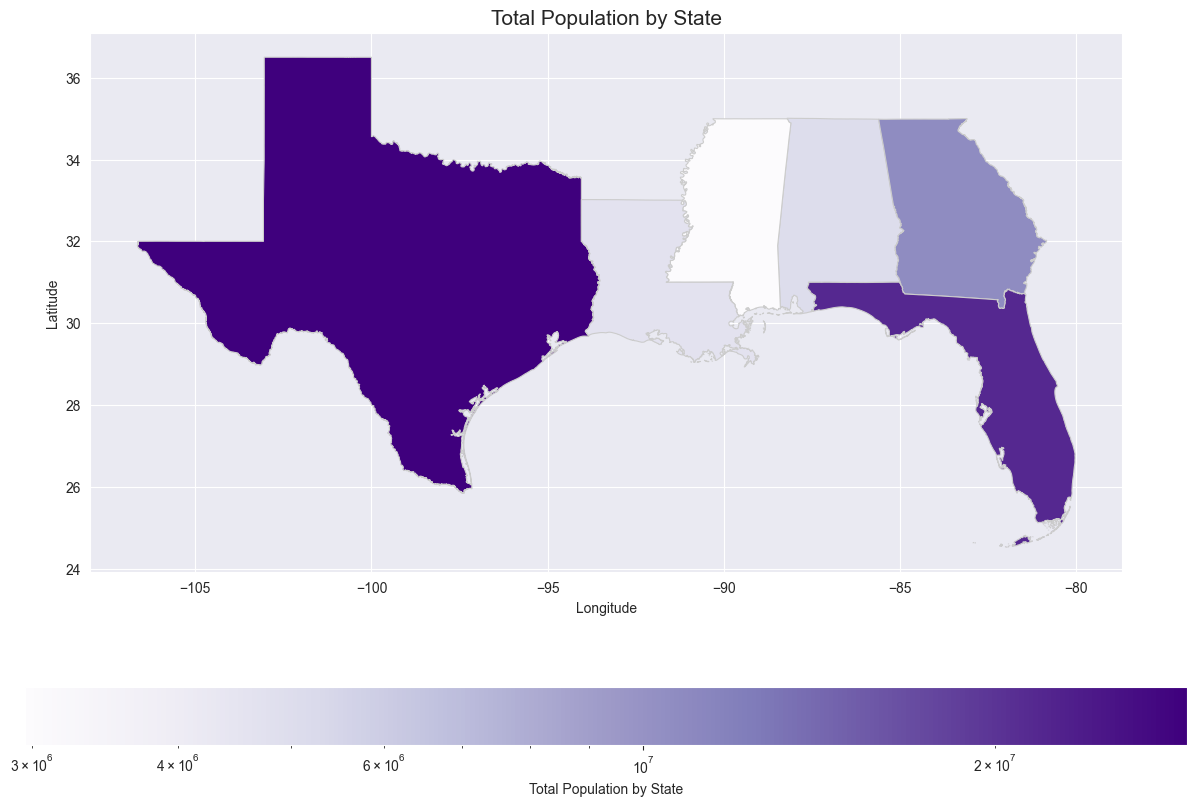

In [30]:
state_pop_data = svi_data.groupby(['STUSPS', 'STATE'])['E_TOTPOP'].sum().reset_index() #Aggregates estimated popoulation from county to state level

complete_pop_data = pd.merge(states, state_pop_data, on='STUSPS', how='left') #Merges state population with state dataframe

complete_pop_data.dropna(subset=['E_TOTPOP'], inplace=True) #Drops rows with NaN values in population column

fig, ax = plt.subplots(1, 1, figsize=(15, 10)) #Creates plot

# Plot states, colored by E_TOTPOP
complete_pop_data.plot(column='E_TOTPOP', #Plots estimated population for each state on the map
                   cmap='Purples', 
                   linewidth=0.8,
                   ax=ax,
                   edgecolor='0.8',
                   legend=True,
                   legend_kwds={'label': "Total Population by State",
                                'orientation': "horizontal"},
                   norm=mpc.LogNorm()) #Uses LogNorm for better visualization of population, along with other customizations

#Creates title and labels
ax.set_title('Total Population by State', fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

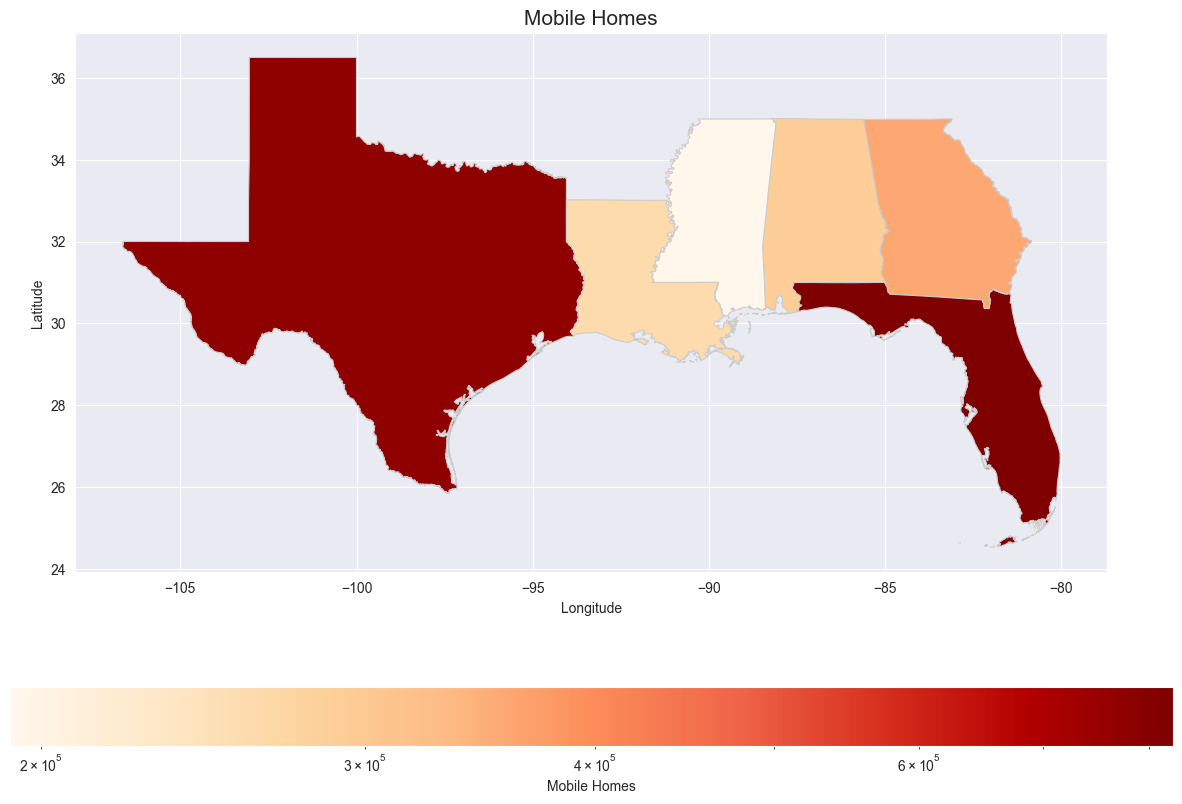

In [32]:
mobile_home_data = svi_data.groupby(['STUSPS', 'STATE'])['E_MOBILE'].sum().reset_index() #Aggregates county mobile home data by state

complete_mobile_count_data = pd.merge(states, mobile_home_data, on='STUSPS', how='left') #Merges mobile home count with state dataframe

complete_mobile_count_data.dropna(subset=['E_MOBILE'], inplace=True) #Drops rows with NaN values in mobile home count

fig, ax = plt.subplots(1, 1, figsize=(15, 10)) #Creates plot

complete_mobile_count_data.plot(column='E_MOBILE', #Plots mobile home count in each state
                   cmap='OrRd', 
                   linewidth=0.8,
                   ax=ax,
                   edgecolor='0.8',
                   legend=True,
                   legend_kwds={'label': "Mobile Homes",
                                'orientation': "horizontal"},
                   norm=mpc.LogNorm()) #Uses LogNorm for better visualization 

#Creates title and labels
ax.set_title('Mobile Homes', fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

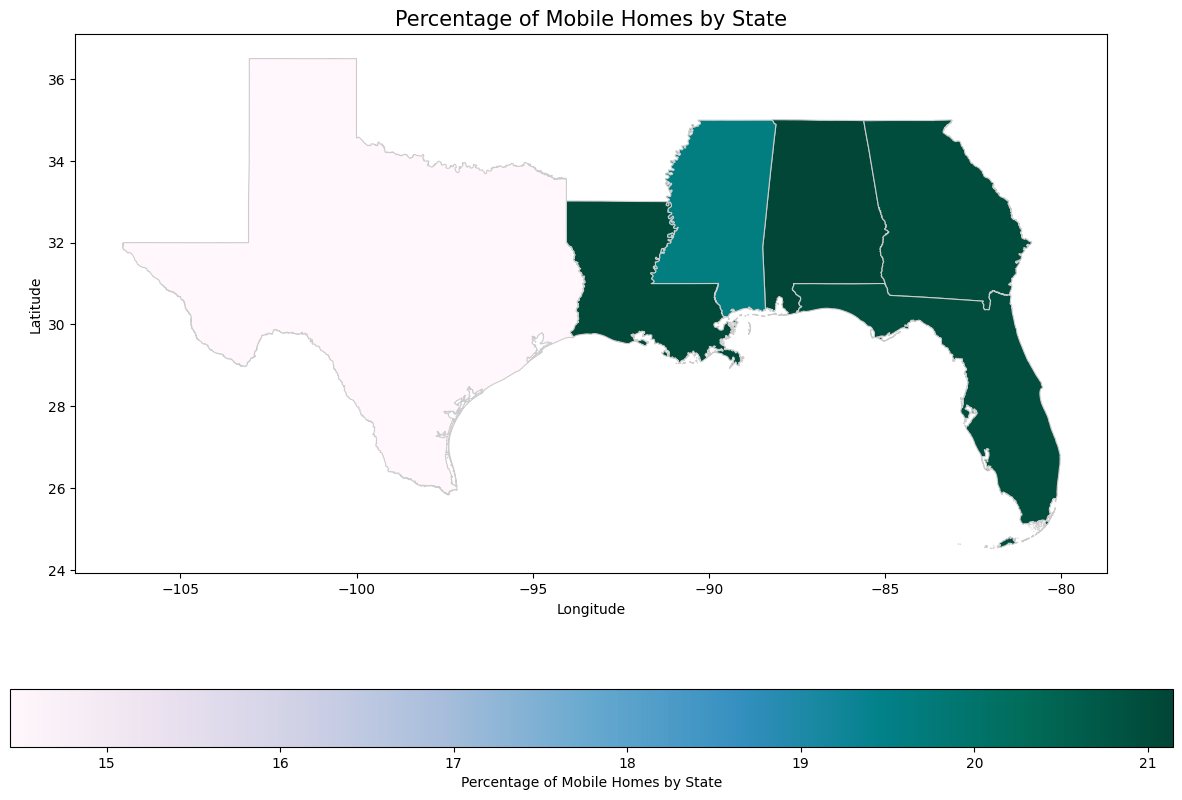

In [12]:


state_mobile_home_data = svi_data.groupby(['STUSPS', 'STATE'])['EP_MOBILE'].mean().reset_index() #Aggregates mobile home percentage by county to state

complete_data_mobile_pct = pd.merge(states, state_mobile_home_data, on='STUSPS', how='left') #Merges mobile home percent with state dataframe

complete_data_mobile_pct.dropna(subset=['EP_MOBILE'], inplace=True) #Drops rows with NaN values in mobile home percent

fig, ax = plt.subplots(1, 1, figsize=(15, 10)) #Creates a figure

# Plot states, colored by EP_MBLHOM
complete_data_mobile_pct.plot(column='EP_MOBILE',  #Plots mobile home percent for each state
                   cmap='PuBuGn', 
                   linewidth=0.8,
                   ax=ax,
                   edgecolor='0.8',
                   legend=True,
                   legend_kwds={'label': "Percentage of Mobile Homes by State",
                                'orientation': "horizontal"})

#Creates title and labels
ax.set_title('Percentage of Mobile Homes by State', fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

Text(0.5, 1.0, 'Total Uninsured Population by State')

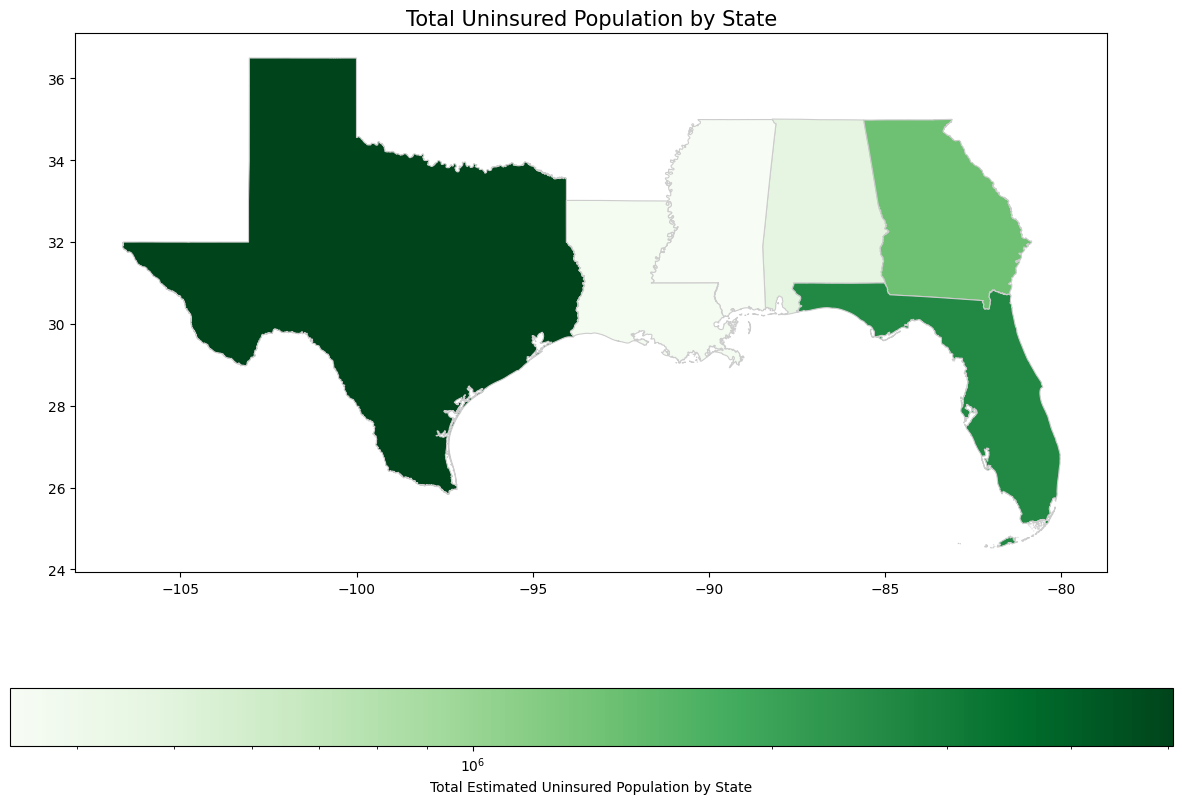

In [9]:
# Aggregate E_TOTPOP from county level to state level
state_pop_data = svi_data.groupby(['STUSPS', 'STATE'])['E_UNINSUR'].sum().reset_index()

# Merge state_pop_data with states GeoDataFrame
complete_data = pd.merge(states, state_pop_data, on='STUSPS', how='left')

# Drop rows with NaN in 'E_TOTPOP' for states not found in SVI data
complete_data.dropna(subset=['E_UNINSUR'], inplace=True)

# Plotting the state populations
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot states, colored by E_TOTPOP
complete_data.plot(column='E_UNINSUR',
                   cmap='Greens',
                   linewidth=0.8,
                   ax=ax,
                   edgecolor='0.8',
                   legend=True,
                   legend_kwds={'label': "Total Estimated Uninsured Population by State",
                                'orientation': "horizontal"},
                   norm=mpc.LogNorm()) # Use LogNorm for better visualization of varying populations

ax.set_title('Total Uninsured Population by State', fontsize=15)

Text(0.5, 1.0, 'Total Population 65 and Older by State')

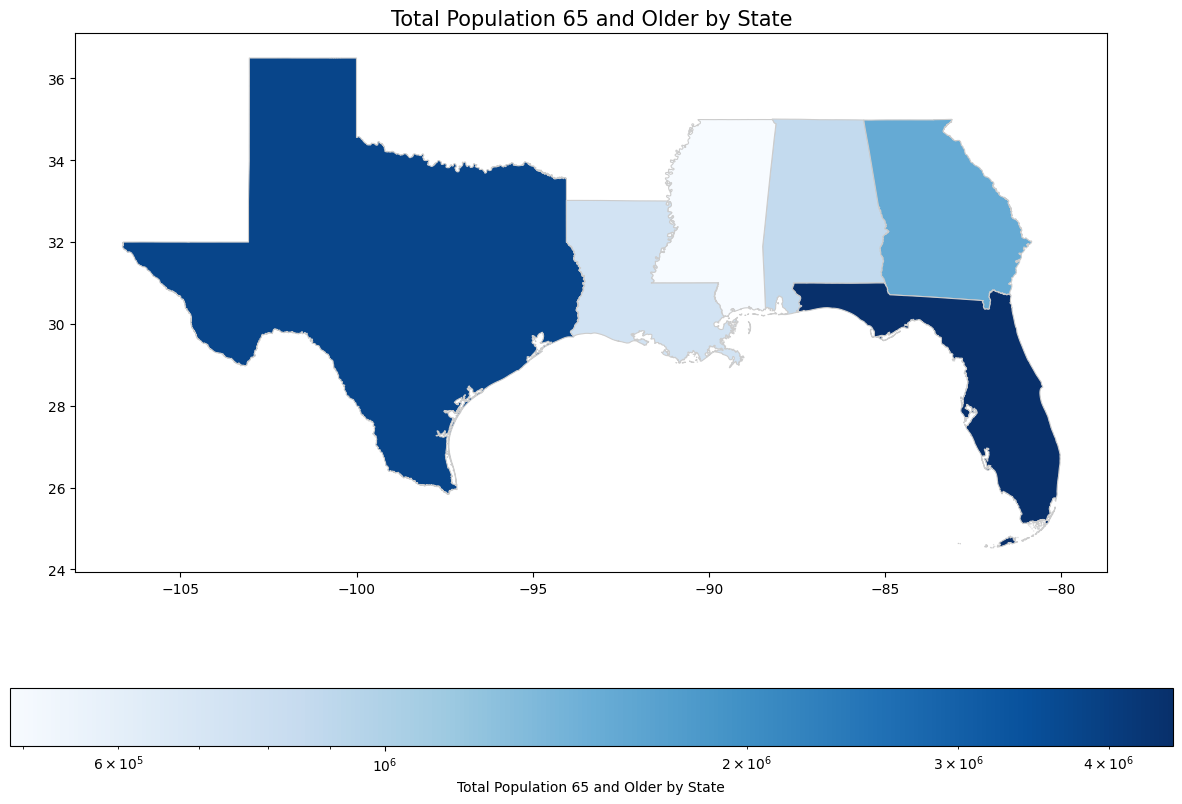

In [10]:
# Aggregate E_TOTPOP from county level to state level
state_pop_data = svi_data.groupby(['STUSPS', 'STATE'])['E_AGE65'].sum().reset_index()

# Merge state_pop_data with states GeoDataFrame
complete_data = pd.merge(states, state_pop_data, on='STUSPS', how='left')

# Drop rows with NaN in 'E_TOTPOP' for states not found in SVI data
complete_data.dropna(subset=['E_AGE65'], inplace=True)

# Plotting the state populations
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot states, colored by E_TOTPOP
complete_data.plot(column='E_AGE65',
                   cmap='Blues',
                   linewidth=0.8,
                   ax=ax,
                   edgecolor='0.8',
                   legend=True,
                   legend_kwds={'label': "Total Population 65 and Older by State",
                                'orientation': "horizontal"},
                   norm=mpc.LogNorm()) # Use LogNorm for better visualization of varying populations

ax.set_title('Total Population 65 and Older by State', fontsize=15)

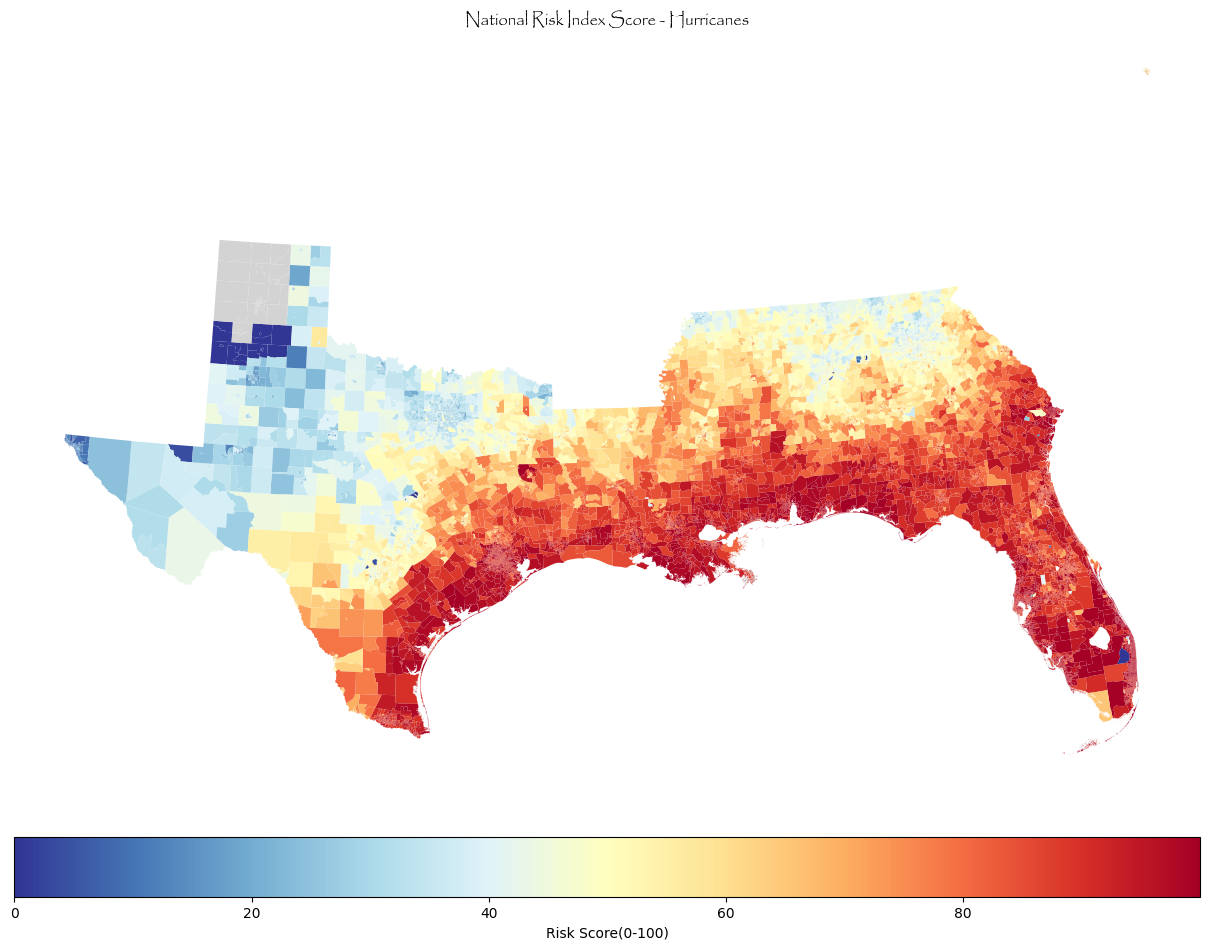

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(18, 10)) #creates plot

#Adds NRI hurricane data
tracts_final.plot(column = 'HRCN_RISKS', ax = ax, legend = True, linewidth = 0.0, cmap = 'RdYlBu_r', legend_kwds = {'label': 'Risk Score(0-100)', 'orientation': 'horizontal', 'shrink':0.67, 'pad':0.05}, missing_kwds = {'color': 'lightgrey', 'label':'No Data'})

ax.set_title('National Risk Index Score - Hurricanes', fontname = 'papyrus') #Adds title
ax.set_axis_off() #Removes axes
plt.tight_layout()

plt.show()

In [75]:
tracts_final['HRCN_RISKS'] = pd.to_numeric(tracts_final['HRCN_RISKS'], errors='coerce')

def assign_risk_level(risk):
    if pd.isna(risk): 
        return 'No Data'
    if risk < 15:
        return 'Marginal'
    elif 15 <= risk < 30:
        return 'Slight'
    elif 30 <= risk < 45:
        return 'Moderate'
    elif 45 <= risk < 60:
        return 'High'
    elif 60 <= risk < 75:
        return 'Very High'
    elif 75 <= risk < 90:
        return 'Profound'
    elif 90 <= risk <= 95:
        return 'Extreme'
    elif 95 <= risk < 101:
        return 'Egregious'

tracts_final['hurricane_risk_level'] = tracts_final['HRCN_RISKS'].apply(assign_risk_level)

In [57]:
tracts_final['hurricane_risk_level']

18320      Extreme
18650      Extreme
18649      Extreme
18648      Extreme
18647      Extreme
           ...    
70116    Very High
70115    Very High
70114    Very High
70137    Very High
23795    Very High
Name: hurricane_risk_level, Length: 18680, dtype: object

In [39]:
tracts_final['HRCN_RISKS']

0        47.836661
1        53.583877
2        56.136818
3        55.376203
4        56.297926
           ...    
76989    80.938144
76990    52.140102
76991    51.168807
76992    63.902530
76993    59.327994
Name: HRCN_RISKS, Length: 18680, dtype: float64

In [76]:
risk_palette = {'No Data' : '#D3D3D3', 'Marginal' : '#93c701', 'Slight' : '#008b00', 'Moderate' : '#ffd701', 'High' : '#f05514', 
               'Very High' : '#dc250e', 'Profound' : '#780000', 'Extreme' : '#b71691', 'Egregious' : '#FF00FF'}

tracts_final['plot_color'] = tracts_final['hurricane_risk_level'].map(risk_palette)

In [77]:
risk_order = ['No Data', 'Marginal', 'Slight', 'Moderate', 'High', 'Very High', 'Profound', 'Extreme', 'Egregious']

# 2. Convert your column to a Categorical type with that specific order
tracts_final.loc[:, 'hurricane_risk_level'] = pd.Categorical(
    tracts_final['hurricane_risk_level'], 
    categories=risk_order, 
    ordered=True
)

tracts_final = tracts_final.sort_values('hurricane_risk_level')

# 3. Create a list of colors that matches the order of your categories
color_list = [risk_palette[level] for level in risk_order]

# 4. Plot using 'categorical=True' and passing the color list as a ListedColormap
custom_cmap = mpc.ListedColormap(color_list)

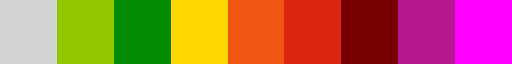

In [78]:
custom_cmap

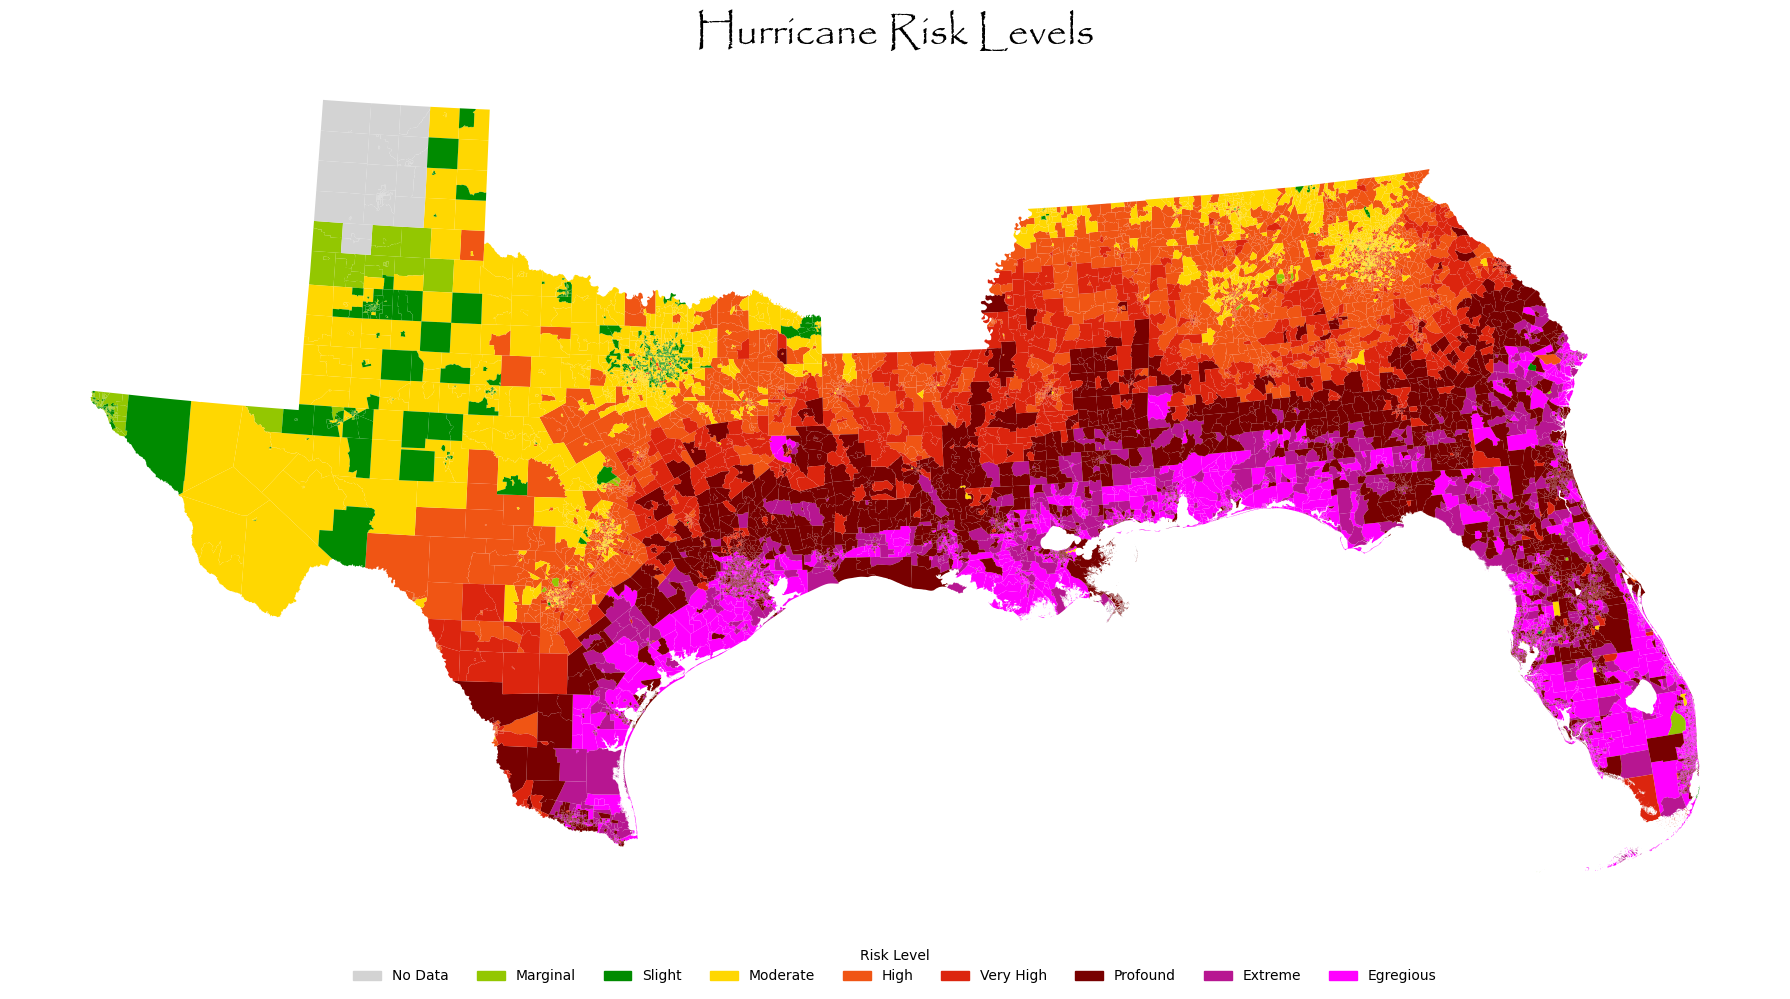

In [80]:
legend_handles = [
    mpatches.Patch(color=risk_palette[level], label=level) 
    for level in risk_order]

fig, ax = plt.subplots(1, 1, figsize=(18, 10)) #creates plot

#Adds NRI hurricane data
tracts_final.plot(ax = ax, legend = True, color=tracts_final['plot_color'], linewidth = 0.0, missing_kwds = {'color': 'lightgrey', 'label':'No Data'})

ax.legend(
    handles=legend_handles, 
    title="Risk Level",
    loc='lower center',
    ncol=9,
    bbox_to_anchor=(0.5, -0.1),
    frameon=False)

ax.set_title('Hurricane Risk Levels', fontname = 'papyrus', fontsize = 30) #Adds title
ax.set_axis_off() #Removes axes
plt.tight_layout()

plt.show()